In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [16]:
# Load the dataset
df = pd.read_csv('/content/diabetes.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
# Basic info and statistics
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [18]:
# Check for zero values in columns where zero is not valid
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zero:
    print(f"{col}: {(df[col] == 0).sum()} zeros")

Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


In [19]:
# Preprocessing: Replace zero with NaN and then impute with median
df_clean = df.copy()
for col in cols_with_zero:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Check missing values
df_clean.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [20]:
# Impute with median (ignoring NaN)
for col in cols_with_zero:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)

# Verify no more zeros in those columns
(df_clean[cols_with_zero] == 0).sum()

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [21]:
# Separate features and target
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

In [22]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (614, 8)
Test set size: (154, 8)


In [23]:
# Feature scaling (important for SVM and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Define models
# SVM with different kernels
svm_linear = SVC(kernel='linear', random_state=42)
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_sigmoid = SVC(kernel='sigmoid', random_state=42)
svm_poly = SVC(kernel='poly', degree=3, random_state=42)  # default degree=3

# KNN (default n_neighbors=5)
knn = KNeighborsClassifier()

models = {
    'SVM Linear': svm_linear,
    'SVM RBF': svm_rbf,
    'SVM Sigmoid': svm_sigmoid,
    'SVM Polynomial': svm_poly,
    'KNN (k=5)': knn
}

In [25]:
# Train and evaluate each model
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        'accuracy': acc,
        'confusion_matrix': cm,
        'classification_report': cr
    }

    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))


--- SVM Linear ---
Accuracy: 0.7013
Confusion Matrix:
[[82 18]
 [28 26]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154


--- SVM RBF ---
Accuracy: 0.7403
Confusion Matrix:
[[84 16]
 [24 30]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


--- SVM Sigmoid ---
Accuracy: 0.7013
Confusion Matrix:
[[76 24]
 [22 32]]
Classification Report:
              precision    recall  f1-score   support

  

In [26]:
# Compare models
# Extract accuracies
accuracies = {name: results[name]['accuracy'] for name in results}
acc_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])
print(acc_df.sort_values('Accuracy', ascending=False))

            Model  Accuracy
4       KNN (k=5)  0.753247
1         SVM RBF  0.740260
3  SVM Polynomial  0.714286
0      SVM Linear  0.701299
2     SVM Sigmoid  0.701299


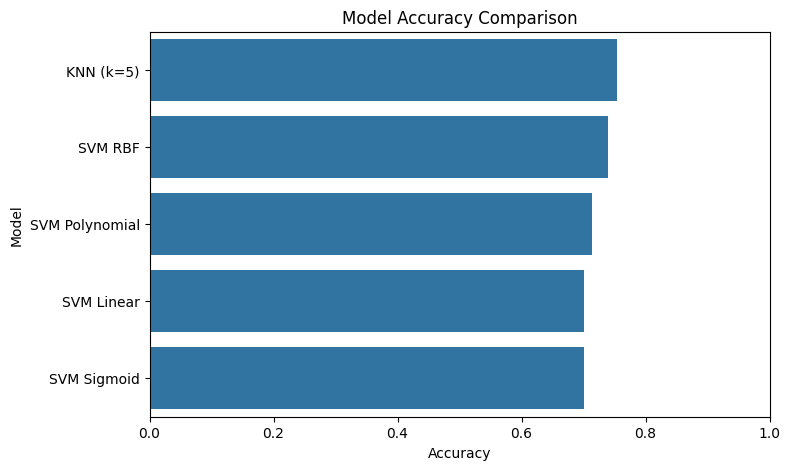

In [27]:
# Plot accuracies
plt.figure(figsize=(8,5))
sns.barplot(x='Accuracy', y='Model', data=acc_df.sort_values('Accuracy', ascending=False))
plt.title('Model Accuracy Comparison')
plt.xlim(0,1)
plt.show()